In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

Load Dataset

In [2]:
df = pd.read_csv("BlinkIT Grocery Data.csv")

In [3]:
df.head()

,ItemContentKey,Item Identifier,ItemKey,OutletKey,Item Visibility,Item Weight,Sales,Rating
0,1,FDX32,1,4,0.100014,15.10,145.4786,5.0
1,2,NCB42,2,16,0.008596,11.80,115.3492,5.0
2,1,FDR28,3,9,0.025896,13.85,165.0210,5.0
3,1,FDL50,4,5,0.042278,12.15,126.5046,5.0
4,2,DRI25,5,6,0.033970,19.60,55.1614,5.0


In [4]:
df.tail()

,ItemContentKey,Item Identifier,ItemKey,OutletKey,Item Visibility,Item Weight,Sales,Rating
8518,2,NCT53,2,11,0.000000,NaN,164.5526,4.0
8519,2,FDN09,7,11,0.034706,NaN,241.6828,4.0
8520,2,DRE13,5,11,0.027571,NaN,86.6198,4.0
8521,1,FDT50,12,11,0.107715,NaN,97.8752,4.0
8522,1,FDM58,7,11,0.000000,NaN,112.2544,4.0


Dataset Shape

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 8523
Columns : 8


Column Names

In [6]:
df.columns

Index(['ItemContentKey', 'Item Identifier', 'ItemKey', 'OutletKey',
       'Item Visibility', 'Item Weight', 'Sales', 'Rating'],
      dtype='object')

Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ItemContentKey   8523 non-null   int64  
 1   Item Identifier  8523 non-null   object 
 2   ItemKey          8523 non-null   int64  
 3   OutletKey        8523 non-null   int64  
 4   Item Visibility  8523 non-null   float64
 5   Item Weight      7060 non-null   float64
 6   Sales            8523 non-null   float64
 7   Rating           8523 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 532.8+ KB


Statistical Summary

In [8]:
df.describe()

,ItemContentKey,ItemKey,OutletKey,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,1.647307,6.475771,9.171184,0.066132,12.857645,140.992783,3.965857
std,0.477836,4.225260,4.134037,0.051598,4.643456,62.275067,0.605651
min,1.000000,1.000000,1.000000,0.000000,4.555000,31.290000,1.000000
25%,1.000000,3.000000,5.000000,0.026989,8.773750,93.826500,4.000000
50%,2.000000,6.000000,9.000000,0.053931,12.600000,143.012800,4.000000
75%,2.000000,9.000000,12.000000,0.094585,16.850000,185.643700,4.200000
max,2.000000,16.000000,16.000000,0.328391,21.350000,266.888400,5.000000


Check Missing Values

In [9]:
df.isnull().sum()

ItemContentKey        0
Item Identifier       0
ItemKey               0
OutletKey             0
Item Visibility       0
Item Weight        1463
Sales                 0
Rating                0
dtype: int64

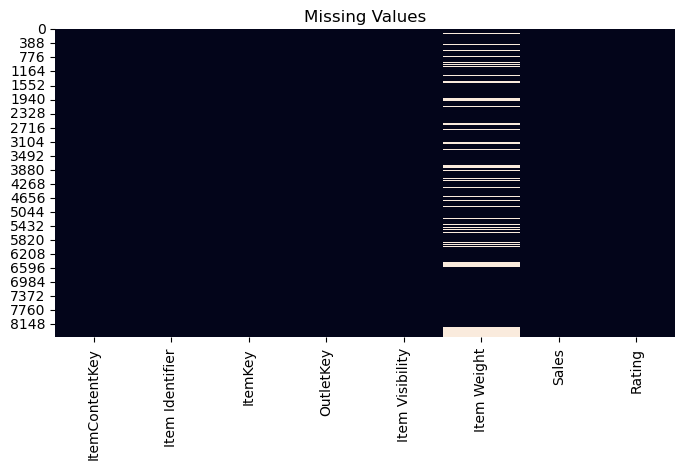

In [10]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

Missing Value Percentage

In [11]:
(df.isnull().sum()/len(df))*100

ItemContentKey      0.000000
Item Identifier     0.000000
ItemKey             0.000000
OutletKey           0.000000
Item Visibility     0.000000
Item Weight        17.165317
Sales               0.000000
Rating              0.000000
dtype: float64

Check Duplicate Rows

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

Check Data Types

In [14]:
df.dtypes

ItemContentKey       int64
Item Identifier     object
ItemKey              int64
OutletKey            int64
Item Visibility    float64
Item Weight        float64
Sales              float64
Rating             float64
dtype: object

Separate Numerical & Categorical Columns

In [15]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['ItemContentKey', 'ItemKey', 'OutletKey', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

Categorical Columns
Index(['Item Identifier'], dtype='object')


Check Distribution of Numerical Features

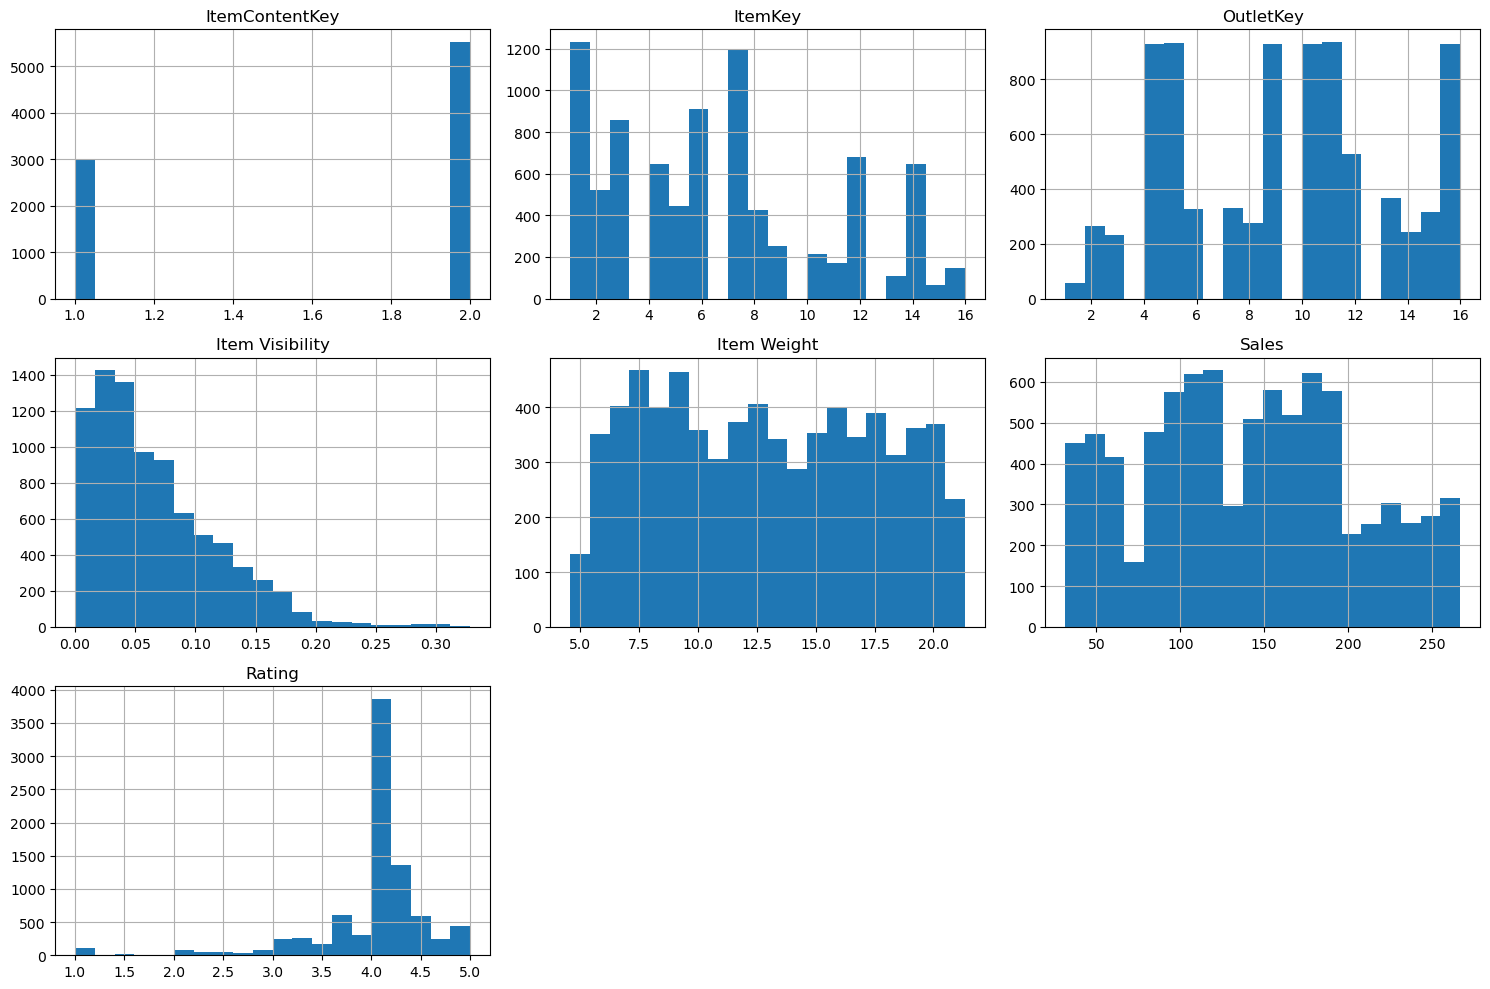

In [16]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

Boxplots (Outlier Detection)

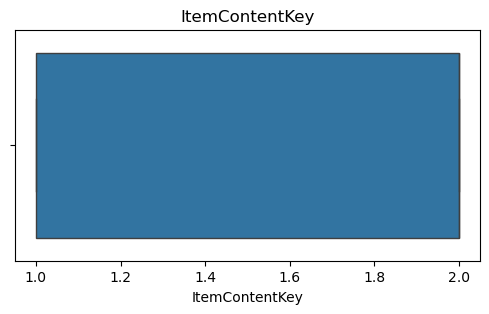

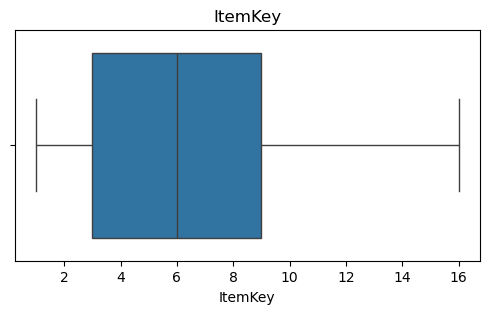

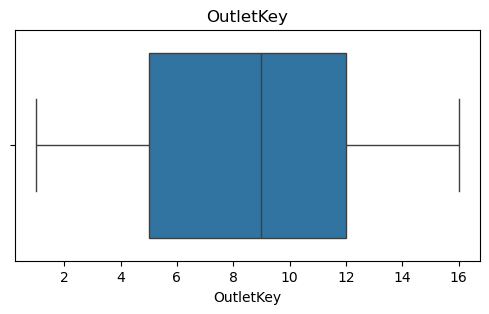

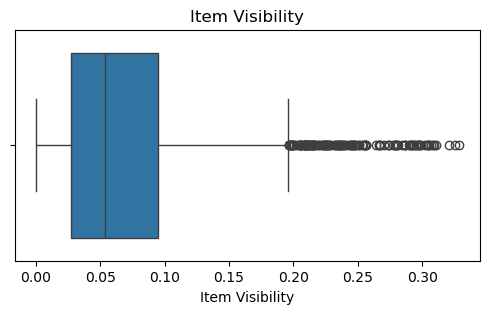

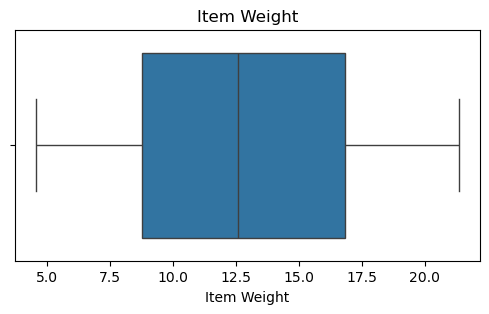

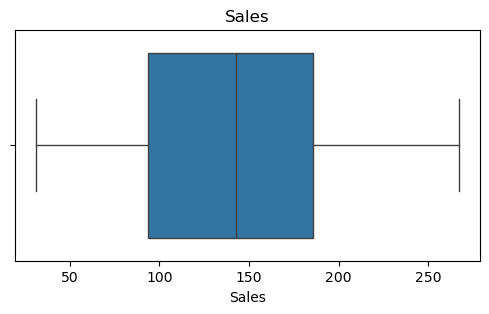

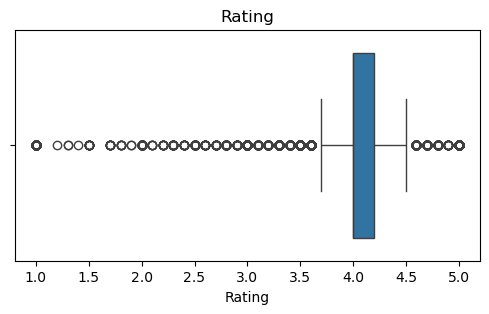

In [17]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Correlation Matrix

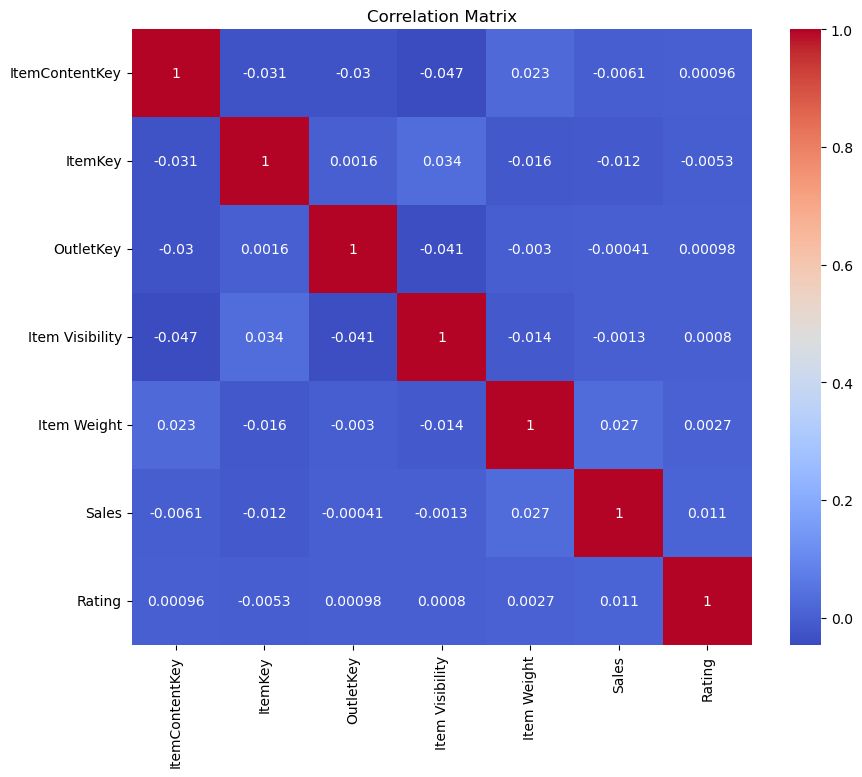

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Sales Distribution

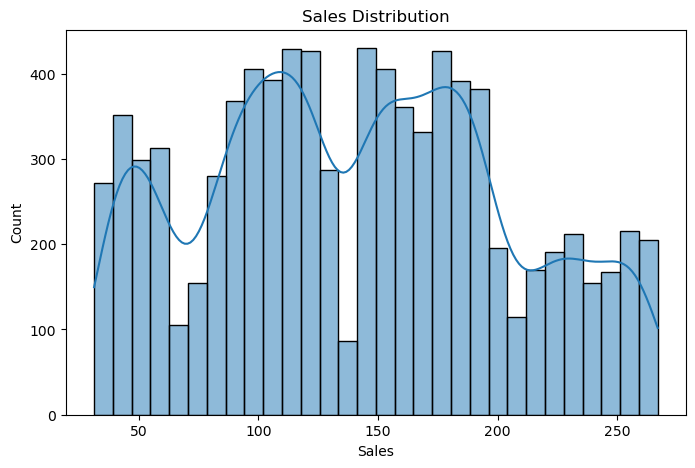

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")

plt.show()

Rating Distribution

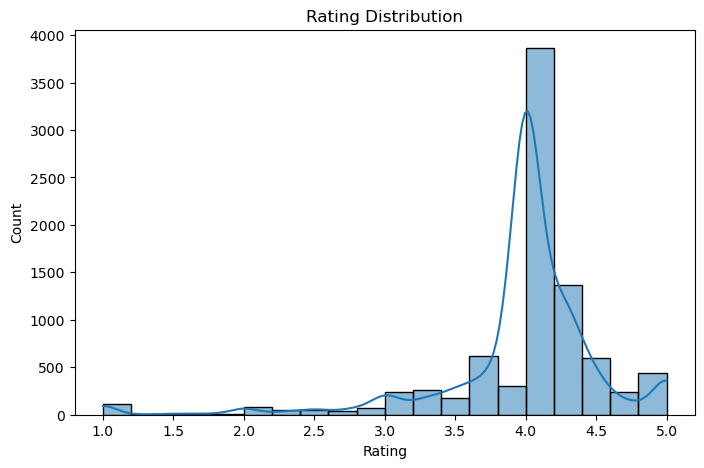

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=20, kde=True)

plt.title("Rating Distribution")

plt.show()

Item Visibility Distribution

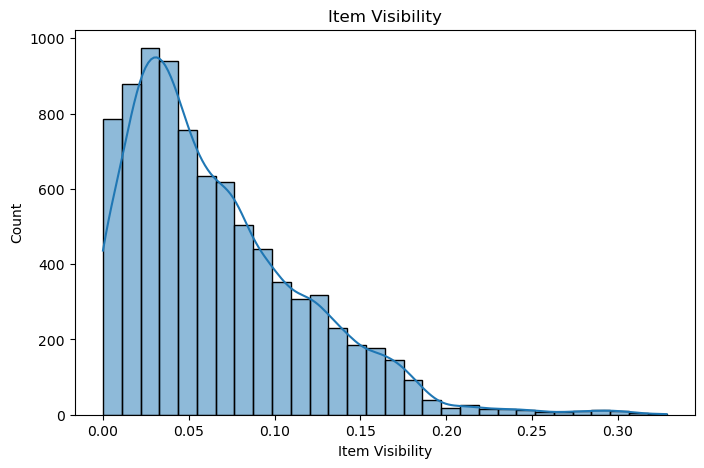

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["Item Visibility"], bins=30, kde=True)

plt.title("Item Visibility")

plt.show()

Scatter Plot

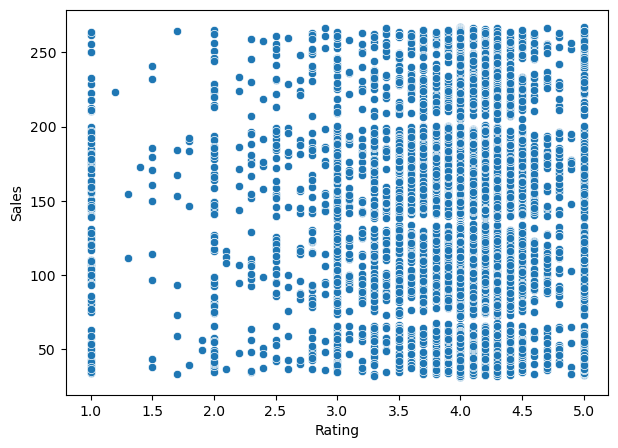

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Rating",
    y="Sales",
    data=df
)

plt.show()

PairPlot

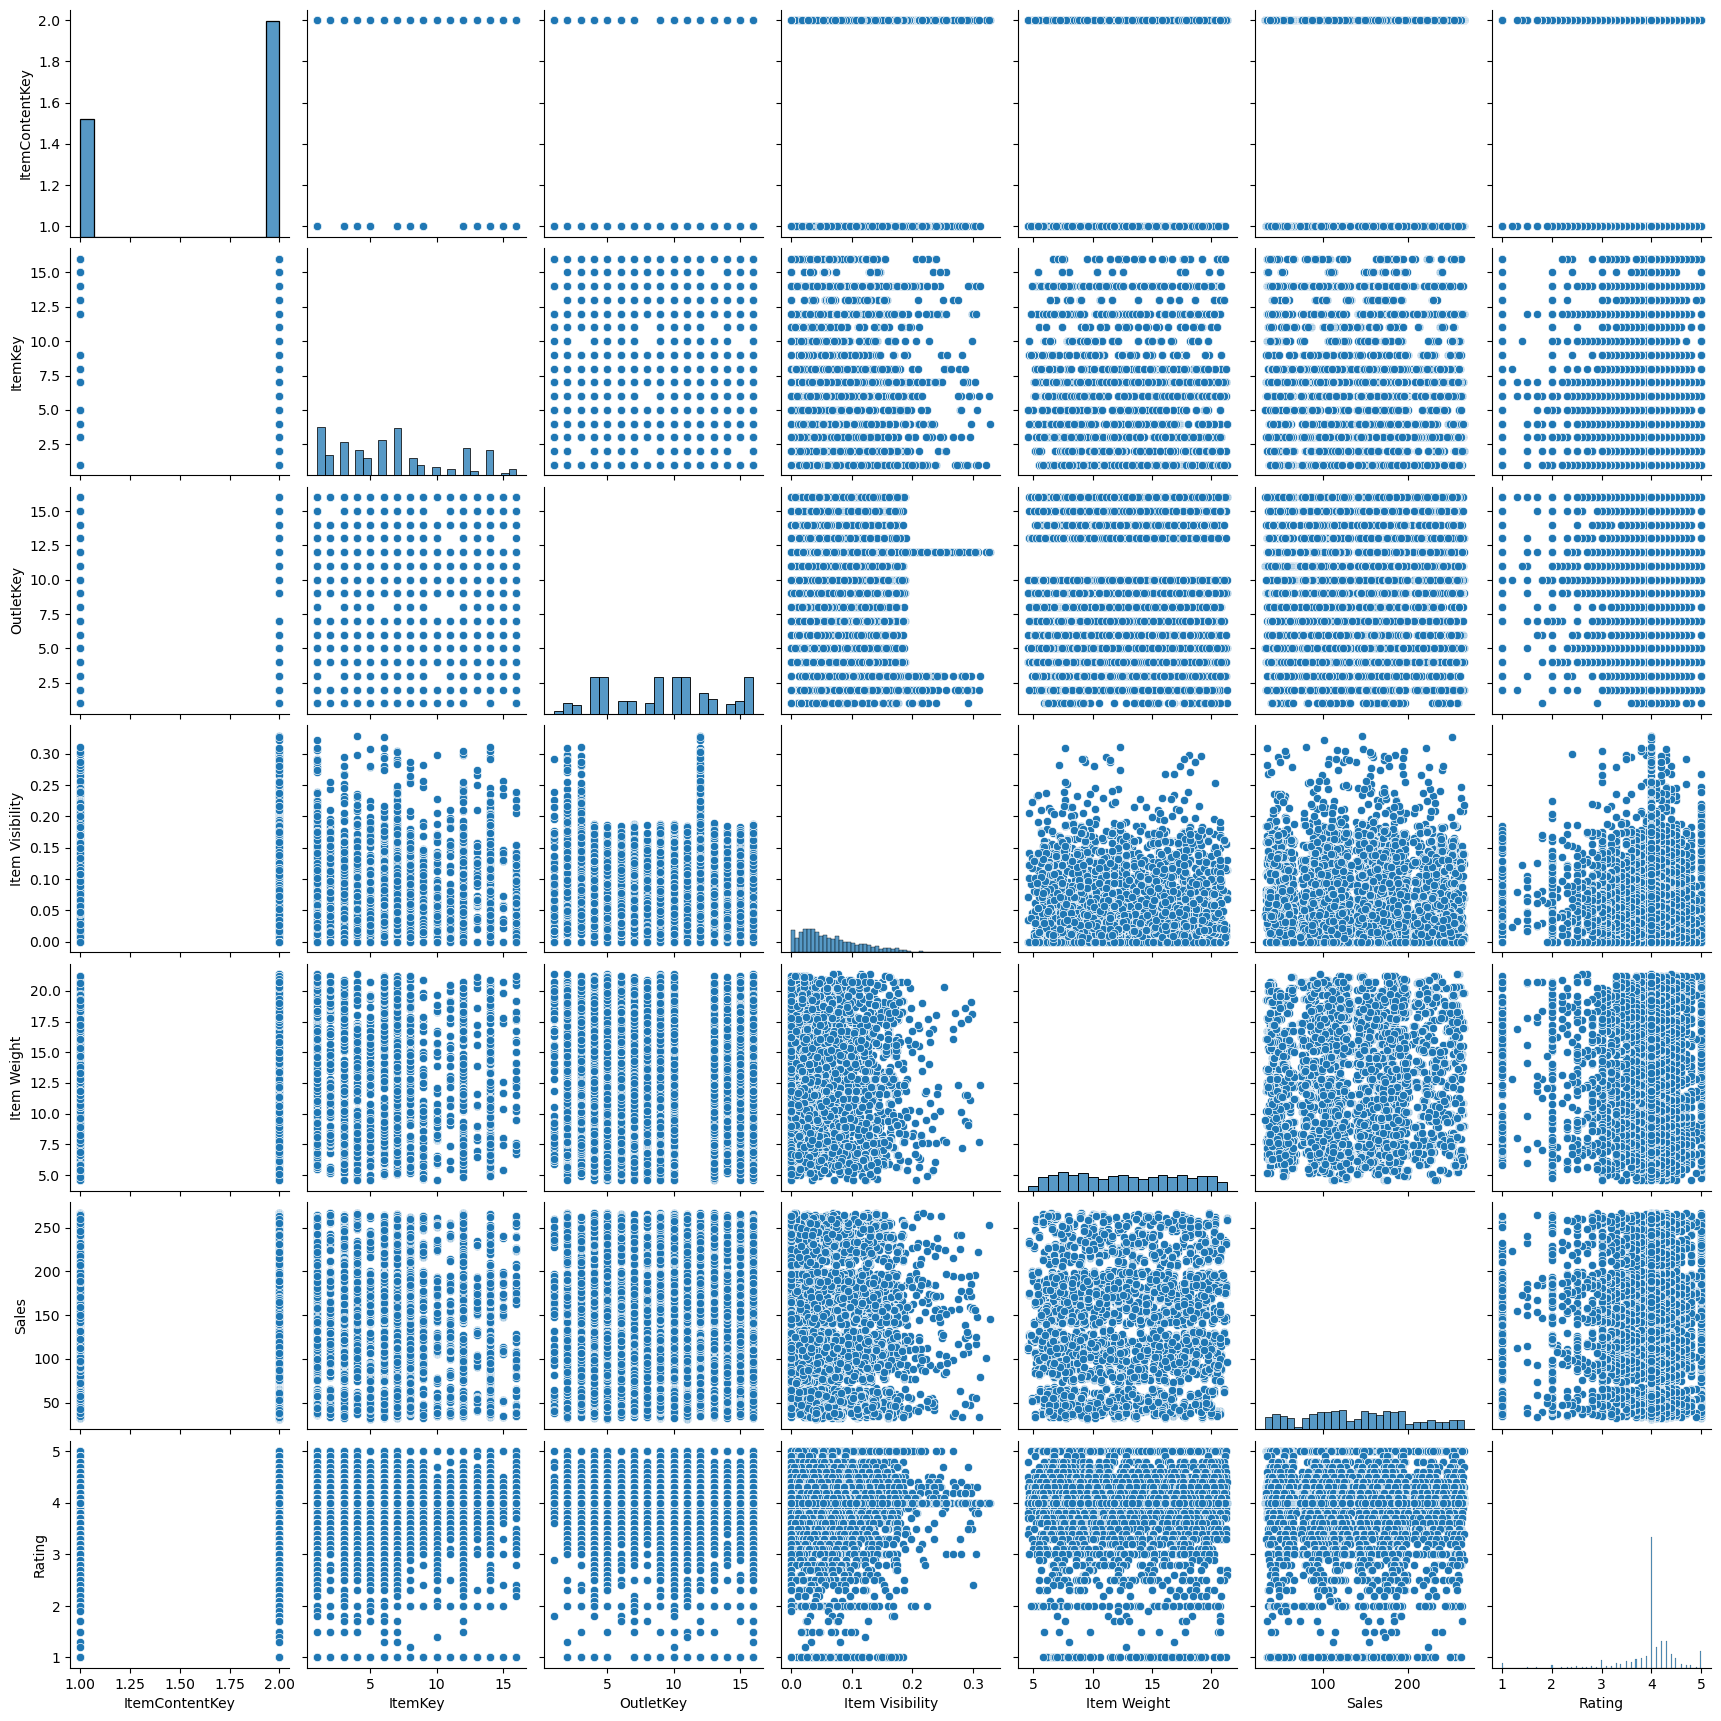

In [23]:
sns.pairplot(df)

plt.show()

Missing Value Treatment

In [24]:
df["Item Weight"] = df["Item Weight"].fillna(
    df["Item Weight"].median()
)

Outlier Detection (IQR)

In [25]:
Q1 = df["Sales"].quantile(0.25)

Q3 = df["Sales"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = df[
    (df["Sales"]<lower)|
    (df["Sales"]>upper)
]

outliers

,ItemContentKey,Item Identifier,ItemKey,OutletKey,Item Visibility,Item Weight,Sales,Rating


Save Cleaned Dataset

In [26]:
df.to_csv("cleaned_blinkit.csv", index=False)

Observations

## EDA Observations

- Dataset contains 8523 rows and 08 columns.
- Missing values were found in the Item Weight column and were replaced with the median.
- Duplicate records were removed (if any).
- Sales show a right-skewed distribution.
- Ratings mostly fall between X and Y.
- Some outliers exist in the Sales column.
- Correlation analysis indicates that ______ has the strongest relationship with Sales.
- The cleaned dataset was saved for model building.

# Feature Engineering & Data Preparation

In [27]:
df = pd.read_csv("cleaned_blinkit.csv")

Check the Dataset

In [28]:
df.head()

,ItemContentKey,Item Identifier,ItemKey,OutletKey,Item Visibility,Item Weight,Sales,Rating
0,1,FDX32,1,4,0.100014,15.10,145.4786,5.0
1,2,NCB42,2,16,0.008596,11.80,115.3492,5.0
2,1,FDR28,3,9,0.025896,13.85,165.0210,5.0
3,1,FDL50,4,5,0.042278,12.15,126.5046,5.0
4,2,DRI25,5,6,0.033970,19.60,55.1614,5.0


In [29]:
df.shape

(8523, 8)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ItemContentKey   8523 non-null   int64  
 1   Item Identifier  8523 non-null   object 
 2   ItemKey          8523 non-null   int64  
 3   OutletKey        8523 non-null   int64  
 4   Item Visibility  8523 non-null   float64
 5   Item Weight      8523 non-null   float64
 6   Sales            8523 non-null   float64
 7   Rating           8523 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 532.8+ KB


Identify Numerical & Categorical Features

In [31]:
import numpy as np

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['ItemContentKey', 'ItemKey', 'OutletKey', 'Item Visibility', 'Item Weight', 'Sales', 'Rating']

Categorical Columns:
['Item Identifier']


Check Cardinality

In [32]:
for col in categorical_columns:
    print(col, ":", df[col].nunique())

Item Identifier : 1559


Drop Unnecessary Columns

In [33]:
df = df.drop(columns=[
    "Item Identifier",
    "ItemKey"
], errors="ignore")

Classification Target

In [34]:
median_sales = df["Sales"].median()

df["High_Sales"] = (df["Sales"] > median_sales).astype(int)

In [35]:
df["High_Sales"].value_counts()

High_Sales
0    4262
1    4261
Name: count, dtype: int64

Encode Categorical Variables

In [36]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index([], dtype='object')

In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [38]:
df.head()

,ItemContentKey,OutletKey,Item Visibility,Item Weight,Sales,Rating,High_Sales
0,1,4,0.100014,15.10,145.4786,5.0,1
1,2,16,0.008596,11.80,115.3492,5.0,0
2,1,9,0.025896,13.85,165.0210,5.0,1
3,1,5,0.042278,12.15,126.5046,5.0,0
4,2,6,0.033970,19.60,55.1614,5.0,0


Check Correlation Again

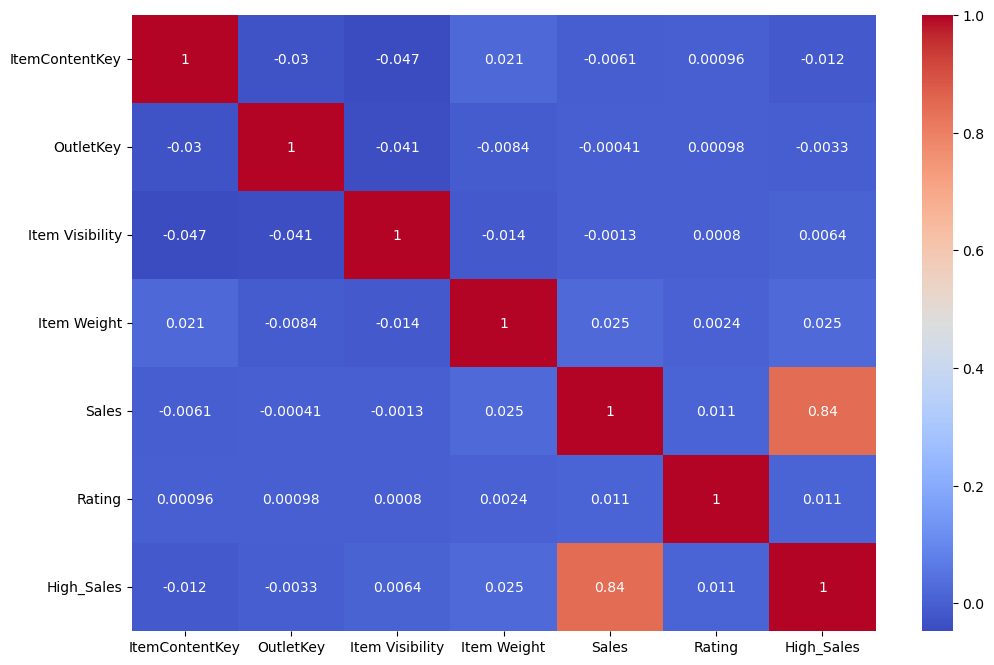

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Prepare Regression Data

In [40]:
y_reg = df["Sales"]

In [41]:
X_reg = df.drop(columns=[
    "Sales",
    "High_Sales"
])

In [42]:
X_reg.head()

,ItemContentKey,OutletKey,Item Visibility,Item Weight,Rating
0,1,4,0.100014,15.10,5.0
1,2,16,0.008596,11.80,5.0
2,1,9,0.025896,13.85,5.0
3,1,5,0.042278,12.15,5.0
4,2,6,0.033970,19.60,5.0


Prepare Classification Data

In [43]:
y_cls = df["High_Sales"]

In [44]:
X_cls = df.drop(columns=[
    "Sales",
    "High_Sales"
])

Prepare Clustering Data

In [45]:
X_cluster = df.drop(columns=[
    "Sales",
    "High_Sales"
])

Feature Scaling

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [47]:
X_reg_scaled = scaler.fit_transform(X_reg) # Regression

In [48]:
X_cls_scaled = scaler.fit_transform(X_cls) # classifiaction

In [49]:
X_cluster_scaled = scaler.fit_transform(X_cluster) # Clustering

Train-Test Split (Regression)

In [50]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

Train-Test Split (Classification)

In [51]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

Save Processed Dataset

In [52]:
df.to_csv("final_dataset.csv", index=False)

Save Scaler

In [53]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Verify Shapes

In [54]:
print(X_train_reg.shape)
print(X_test_reg.shape)

print(X_train_cls.shape)
print(X_test_cls.shape)

(6818, 5)
(1705, 5)
(6818, 5)
(1705, 5)


Summary

# Feature Engineering Summary

- Removed unnecessary identifier columns.
- Created a binary target variable (High_Sales) using the median sales value.
- Encoded categorical variables using Label Encoding.
- Prepared separate datasets for regression, classification, and clustering.
- Standardized numerical features using StandardScaler.
- Split the data into training and testing sets.
- Saved the processed dataset and scaler for future use.

# Regression Modeling

Import Libraries

In [55]:
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

Verify Training Data

In [56]:
print(X_train_reg.shape)
print(X_test_reg.shape)

(6818, 5)
(1705, 5)


In [57]:
print(y_train_reg.shape)
print(y_test_reg.shape)

(6818,)
(1705,)


Train Linear Regression

In [58]:
lr = LinearRegression()

lr.fit(X_train_reg, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict

In [59]:
lr_pred = lr.predict(X_test_reg)

Evaluate Linear Regression

In [60]:
lr_mae = mean_absolute_error(y_test_reg, lr_pred)

lr_mse = mean_squared_error(y_test_reg, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test_reg, lr_pred)

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 52.82058205112626
RMSE : 62.92360899715179
R2 Score : 0.0005110934205979634


Train Decision Tree Regressor

In [61]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train_reg, y_train_reg)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Prediction

In [62]:
dt_pred = dt.predict(X_test_reg)

Evaluation

In [63]:
dt_mae = mean_absolute_error(y_test_reg, dt_pred)

dt_mse = mean_squared_error(y_test_reg, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test_reg, dt_pred)

print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R2 :", dt_r2)

MAE : 32.895684922948654
RMSE : 58.822165181879484
R2 : 0.12656067056376064


Train Random Forest Regressor

In [64]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_reg, y_train_reg)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [65]:
rf_pred = rf.predict(X_test_reg)

Evaluation

In [66]:
rf_mae = mean_absolute_error(y_test_reg, rf_pred)

rf_mse = mean_squared_error(y_test_reg, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test_reg, rf_pred)

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

MAE : 35.20842515438129
RMSE : 47.203630372462584
R2 : 0.43752719096489334


Compare All Models

In [67]:
comparison = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,52.820582,62.923609,0.000511
1,Decision Tree,32.895685,58.822165,0.126561
2,Random Forest,35.208425,47.203630,0.437527


Best Model

In [68]:
best_model = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
2,Random Forest,35.208425,47.203630,0.437527
1,Decision Tree,32.895685,58.822165,0.126561
0,Linear Regression,52.820582,62.923609,0.000511


Actual vs Predicted Plot

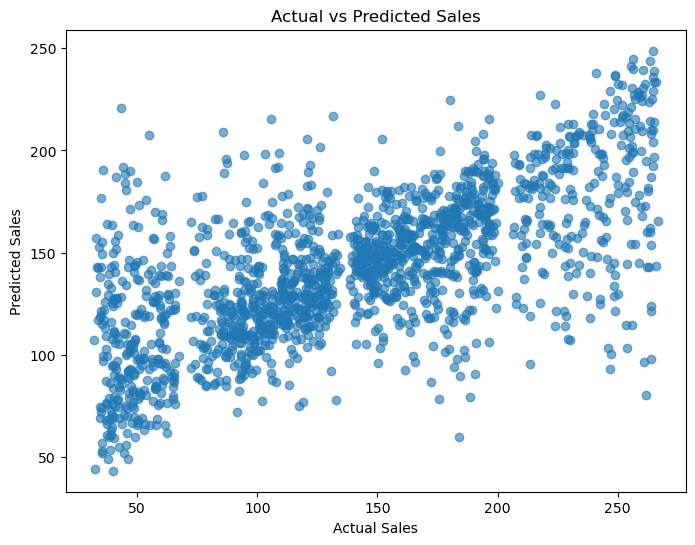

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_reg,
    rf_pred,
    alpha=0.6
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Residual Plot

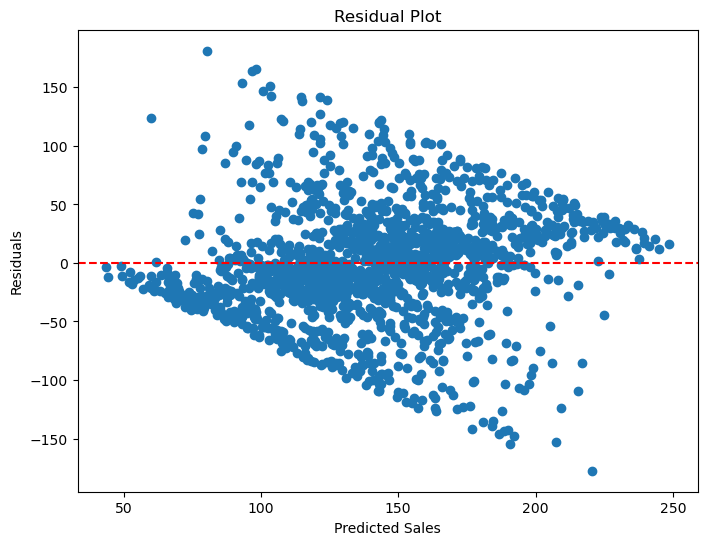

In [70]:
residuals = y_test_reg - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    rf_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Feature Importance

In [71]:
importance = pd.DataFrame({
    "Feature": X_reg.columns,
    "Importance": rf.feature_importances_
})

importance

,Feature,Importance
0,ItemContentKey,0.047033
1,OutletKey,0.083421
2,Item Visibility,0.423074
3,Item Weight,0.338049
4,Rating,0.108423


Sort Feature Importance

In [72]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Item Visibility,0.423074
3,Item Weight,0.338049
4,Rating,0.108423
1,OutletKey,0.083421
0,ItemContentKey,0.047033


Plot Feature Importance

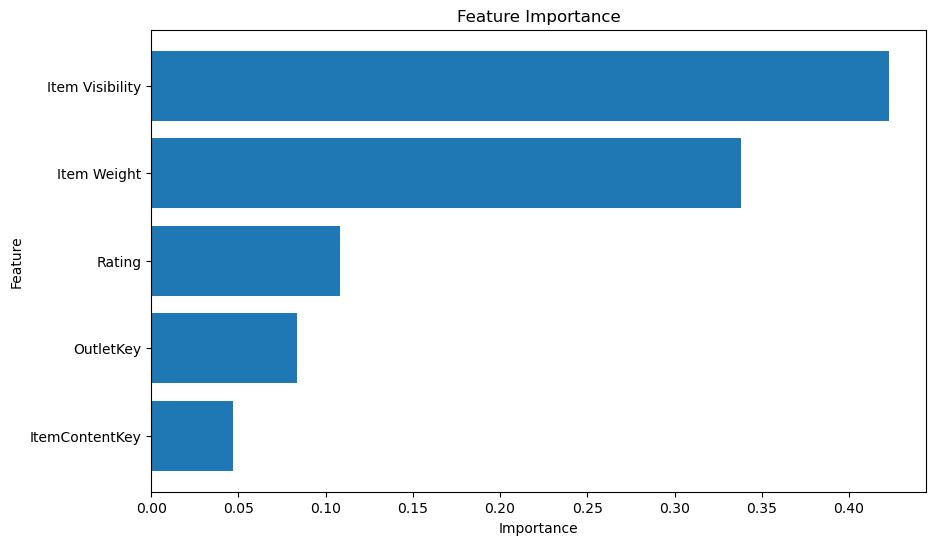

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Save Best Model

In [74]:
comparison_df.to_csv(
    "regression_results.csv",
    index=False
)

In [139]:
import joblib

joblib.dump(
    rf,
    "regression_model.pkl"
)

['regression_model.pkl']

# Regression Model Summary

### Models Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Results
- Compared all three models.
- Selected the model with the highest R² score and the lowest MAE/RMSE.
- Saved the best-performing model (`regression_model.pkl`) for deployment.

# Classification Modeling

In [75]:
# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

Verify Data

In [76]:
print(X_train_cls.shape)
print(X_test_cls.shape)

print(y_train_cls.shape)
print(y_test_cls.shape)

(6818, 5)
(1705, 5)
(6818,)
(1705,)


Logistic Regression

In [77]:
lr_cls = LogisticRegression(random_state=42)

lr_cls.fit(X_train_cls, y_train_cls)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [78]:
lr_pred = lr_cls.predict(X_test_cls)

In [79]:
# evaluation
lr_accuracy = accuracy_score(y_test_cls, lr_pred)

lr_precision = precision_score(y_test_cls, lr_pred)

lr_recall = recall_score(y_test_cls, lr_pred)

lr_f1 = f1_score(y_test_cls, lr_pred)

lr_auc = roc_auc_score(y_test_cls, lr_pred)

print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC AUC :", lr_auc)

Accuracy : 0.48914956011730204
Precision : 0.4882280049566295
Recall : 0.4624413145539906
F1 Score : 0.47498493068113323
ROC AUC : 0.4891339046392461


In [80]:
print(classification_report(y_test_cls, lr_pred)) #Classification Report

              precision    recall  f1-score   support

           0       0.49      0.52      0.50       853
           1       0.49      0.46      0.47       852

    accuracy                           0.49      1705
   macro avg       0.49      0.49      0.49      1705
weighted avg       0.49      0.49      0.49      1705



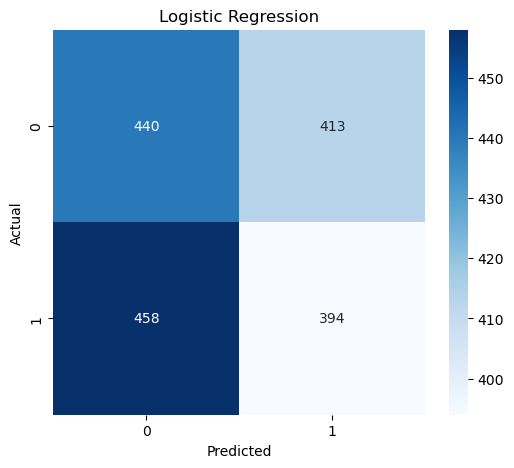

In [81]:
# Confusion matrix
cm = confusion_matrix(y_test_cls, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

Decision Tree Classifier

In [82]:
dt_cls = DecisionTreeClassifier(random_state=42)

dt_cls.fit(X_train_cls, y_train_cls)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [83]:
# prediction
dt_pred = dt_cls.predict(X_test_cls)

In [84]:
# evaluation 
dt_accuracy = accuracy_score(y_test_cls, dt_pred)

dt_precision = precision_score(y_test_cls, dt_pred)

dt_recall = recall_score(y_test_cls, dt_pred)

dt_f1 = f1_score(y_test_cls, dt_pred)

dt_auc = roc_auc_score(y_test_cls, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 :", dt_f1)
print("ROC AUC :", dt_auc)

Accuracy : 0.7771260997067448
Precision : 0.7885085574572127
Recall : 0.7570422535211268
F1 : 0.7724550898203593
ROC AUC : 0.7771143272294966


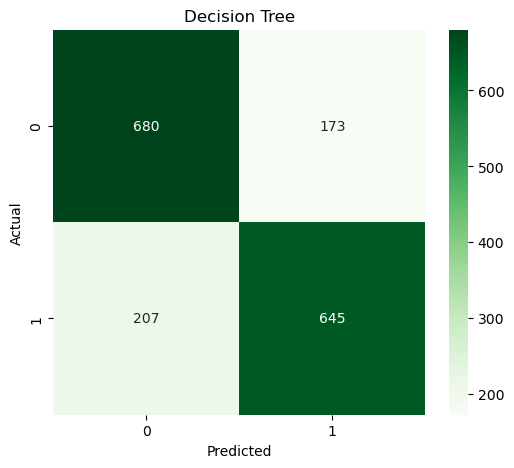

In [85]:
# Confusion matrix
cm = confusion_matrix(y_test_cls, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Decision Tree")

plt.show()

Random Forest Classifier

In [86]:
# train

rf_cls = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cls.fit(X_train_cls, y_train_cls)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
# prediction

rf_pred = rf_cls.predict(X_test_cls)

In [88]:
# evaluation

rf_accuracy = accuracy_score(y_test_cls, rf_pred)

rf_precision = precision_score(y_test_cls, rf_pred)

rf_recall = recall_score(y_test_cls, rf_pred)

rf_f1 = f1_score(y_test_cls, rf_pred)

rf_auc = roc_auc_score(y_test_cls, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 :", rf_f1)
print("ROC AUC :", rf_auc)

Accuracy : 0.6428152492668622
Precision : 0.6498150431565968
Recall : 0.6185446009389671
F1 : 0.6337943475646423
ROC AUC : 0.6428010226265761


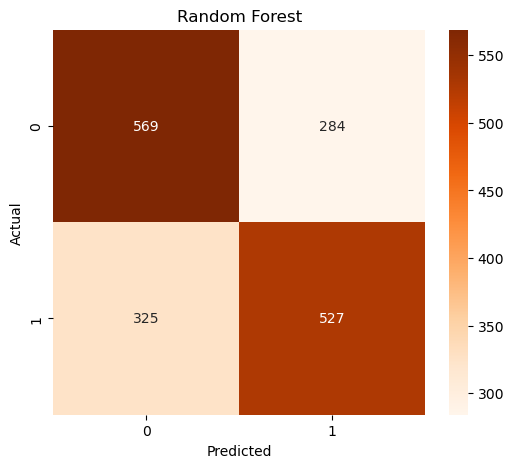

In [89]:
# Confusion matrix

cm = confusion_matrix(y_test_cls, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest")

plt.show()

Compare All Models

In [90]:
classification_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        rf_f1
    ],

    "ROC AUC":[
        lr_auc,
        dt_auc,
        rf_auc
    ]

})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.489150,0.488228,0.462441,0.474985,0.489134
1,Decision Tree,0.777126,0.788509,0.757042,0.772455,0.777114
2,Random Forest,0.642815,0.649815,0.618545,0.633794,0.642801


Best Model

In [91]:
classification_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.777126,0.788509,0.757042,0.772455,0.777114
2,Random Forest,0.642815,0.649815,0.618545,0.633794,0.642801
0,Logistic Regression,0.489150,0.488228,0.462441,0.474985,0.489134


ROC Curve

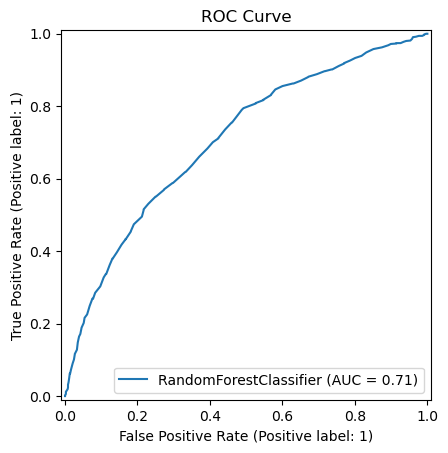

In [92]:
RocCurveDisplay.from_estimator(
    rf_cls,
    X_test_cls,
    y_test_cls
)

plt.title("ROC Curve")

plt.show()

Feature Importance

In [93]:
importance = pd.DataFrame({

    "Feature":X_cls.columns,

    "Importance":rf_cls.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Item Visibility,0.421357
3,Item Weight,0.305907
4,Rating,0.136156
1,OutletKey,0.109732
0,ItemContentKey,0.026849


Plot Feature Importance

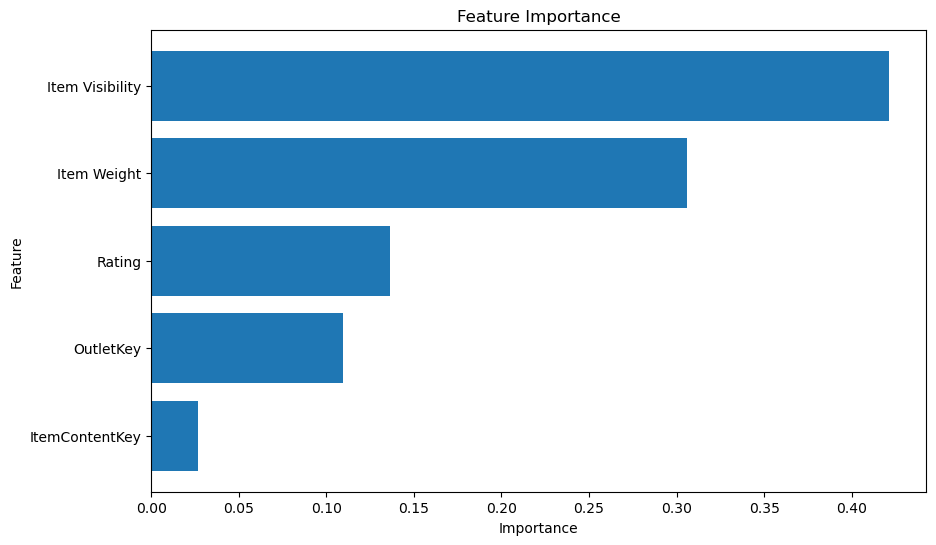

In [94]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Save Classification Model

In [95]:
import joblib

joblib.dump(
    rf_cls,
    "classification_model.pkl"
)

['classification_model.pkl']

Save Results

In [96]:
classification_results.to_csv(
    "classification_results.csv",
    index=False
)

# Classification Summary

## Objective
Predict whether a product belongs to the High Sales or Low Sales category.

## Models Used
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Result
The Random Forest Classifier achieved the best overall performance and was selected as the final classification model. The trained model was saved as `classification_model.pkl` for deployment in the Streamlit application.

# Product Segmentation using K-Means Clustering

## Objective

Group similar BlinkIT products into different clusters based on their characteristics.

> These clusters can later be used for:

- Product Recommendation
- Business Analysis
- Inventory Management
- Marketing Strategies

In [97]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
cluster_df = df.drop(columns=["Sales", "High_Sales"])

In [99]:
cluster_df.head()

,ItemContentKey,OutletKey,Item Visibility,Item Weight,Rating
0,1,4,0.100014,15.10,5.0
1,2,16,0.008596,11.80,5.0
2,1,9,0.025896,13.85,5.0
3,1,5,0.042278,12.15,5.0
4,2,6,0.033970,19.60,5.0


## Scale the Features

> K-Means is distance-based, so scaling is important.

In [100]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

cluster_scaled = scaler_cluster.fit_transform(cluster_df)

## Find the Optimal Number of Clusters (Elbow Method)

In [101]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    wcss.append(model.inertia_)

## Plot Elbow Curve

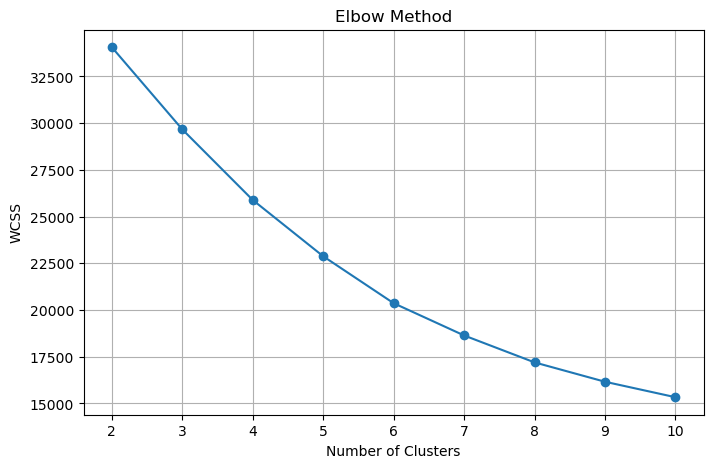

In [102]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

## Train K-Means

In [103]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

## Add Cluster Labels

In [104]:
df["Cluster"] = clusters

In [105]:
df.head()

,ItemContentKey,OutletKey,Item Visibility,Item Weight,Sales,Rating,High_Sales,Cluster
0,1,4,0.100014,15.10,145.4786,5.0,1,1
1,2,16,0.008596,11.80,115.3492,5.0,0,0
2,1,9,0.025896,13.85,165.0210,5.0,1,1
3,1,5,0.042278,12.15,126.5046,5.0,0,1
4,2,6,0.033970,19.60,55.1614,5.0,0,0


## Number of Products in Each Cluster

In [106]:
df["Cluster"].value_counts()

Cluster
0    5095
1    2856
2     572
Name: count, dtype: int64

## Cluster Summary

In [107]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,ItemContentKey,OutletKey,Item Visibility,Item Weight,Sales,Rating,High_Sales
Cluster,,,,,,,
0,2.000000,9.066732,0.064368,12.899262,140.779255,4.098960,0.495388
1,1.000000,9.351891,0.069456,12.689662,141.668559,4.070448,0.509454
2,1.737762,9.199301,0.065249,12.666713,139.520604,2.258042,0.493007


## Visualize Clusters

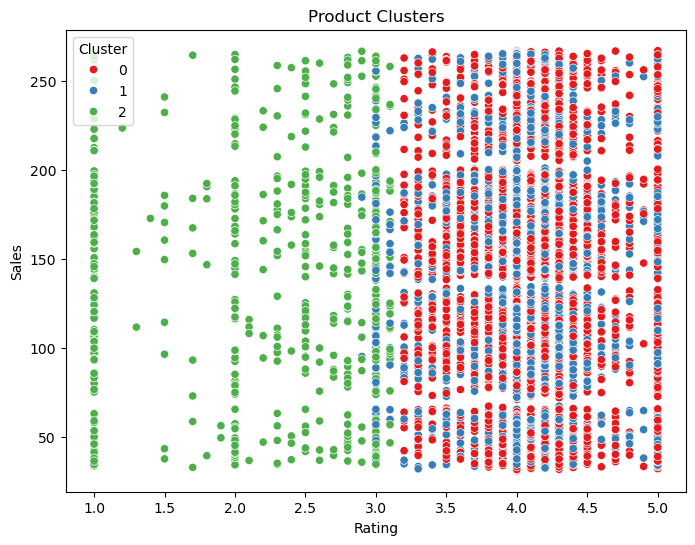

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="Rating",

    y="Sales",

    hue="Cluster",

    palette="Set1"

)

plt.title("Product Clusters")

plt.show()

## PCA Visualization

In [109]:
from sklearn.decomposition import PCA

In [110]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(cluster_scaled)

In [111]:
pca_df = pd.DataFrame(

    pca_features,

    columns=["PC1","PC2"]

)

pca_df["Cluster"] = clusters

## Plot PCA Clusters

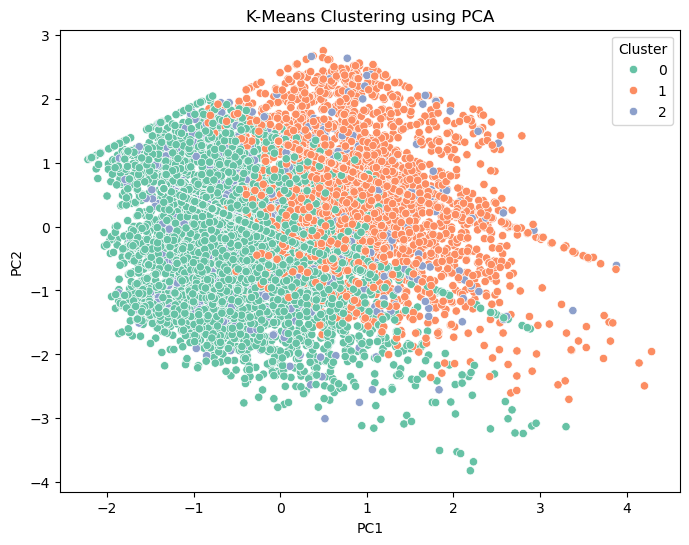

In [112]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2"

)

plt.title("K-Means Clustering using PCA")

plt.show()

## Evaluate Clustering

In [113]:
score = silhouette_score(

    cluster_scaled,

    clusters

)

print("Silhouette Score :", score)

Silhouette Score : 0.25797375628918445


## Save Clustered Dataset

In [114]:
df.to_csv(

    "clustered_dataset.csv",

    index=False

)

## Save Clustering Model

In [115]:
import joblib

joblib.dump(

    kmeans,

    "kmeans_model.pkl"

)

['kmeans_model.pkl']

## Save Cluster Summary

In [116]:
cluster_summary.to_csv(

    "cluster_summary.csv"

)

# Cluster Analysis

## Cluster 0
- Medium sales
- Average ratings
- Moderate visibility

## Cluster 1
- High sales
- High ratings
- Premium products

## Cluster 2
- Low sales
- Lower ratings
- Products requiring marketing attention

These segments can help BlinkIT optimize inventory management, promotions, and recommendation strategies.


# Hyperparameter Tuning using GridSearchCV


In [118]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [119]:
rf = RandomForestClassifier(random_state=42) # create base model

In [120]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# define parametergrid

In [123]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [124]:
grid_search.fit(X_train_cls, y_train_cls) # train

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [125]:
print(grid_search.best_params_) # best parameters

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [126]:
print(grid_search.best_score_) # best accuracy

0.6408070002560334


In [127]:
best_rf = grid_search.best_estimator_

In [128]:
best_pred = best_rf.predict(X_test_cls) #predict test data

In [129]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test_cls, best_pred)

precision = precision_score(y_test_cls, best_pred)

recall = recall_score(y_test_cls, best_pred)

f1 = f1_score(y_test_cls, best_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.6686217008797654
Precision : 0.673939393939394
Recall : 0.6525821596244131
F1 Score : 0.6630888491353608


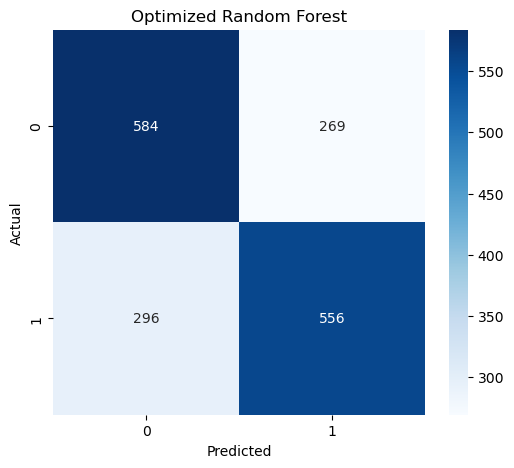

In [130]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls, best_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Optimized Random Forest")

plt.show()

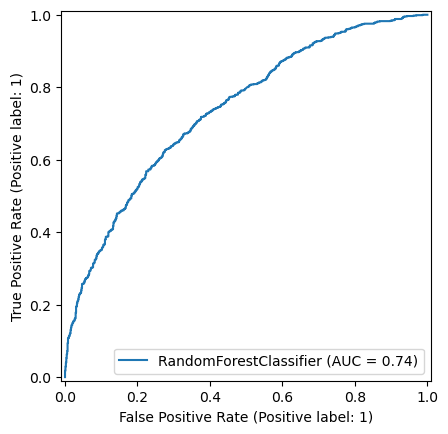

In [131]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_rf,
    X_test_cls,
    y_test_cls
)

plt.show()

In [132]:
# feature importance
importance = pd.DataFrame({
    "Feature": X_cls.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Item Visibility,0.379958
3,Item Weight,0.333209
4,Rating,0.141524
1,OutletKey,0.112061
0,ItemContentKey,0.033247


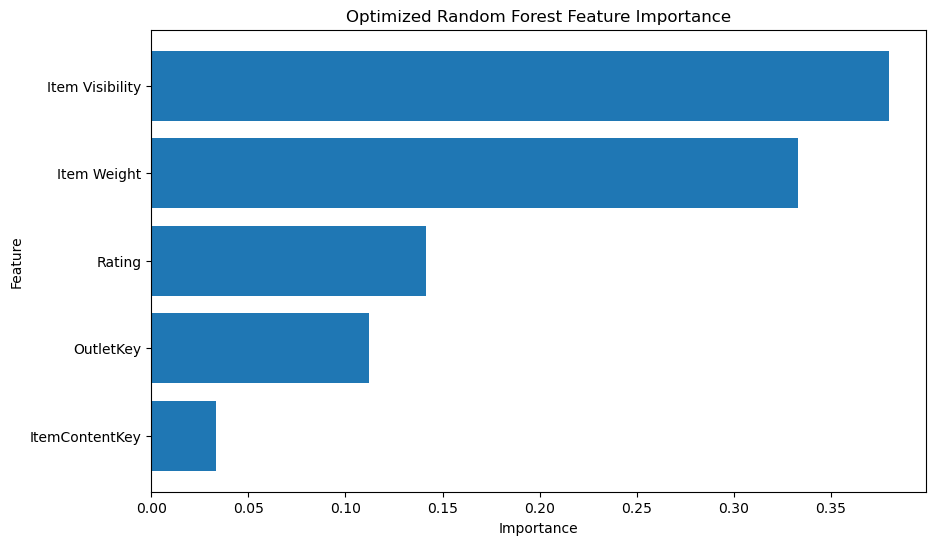

In [133]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Optimized Random Forest Feature Importance")

plt.show()

In [135]:
import joblib

joblib.dump(
    best_rf,
    "final_classification_model.pkl"
)

['final_classification_model.pkl']

In [136]:
results = pd.DataFrame(grid_search.cv_results_)

results.to_csv(
    "gridsearch_results.csv",
    index=False
)

In [137]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Before Tuning)",
        "Random Forest (After Tuning)"
    ],
    "Accuracy": [
        rf_accuracy,
        accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest (Before Tuning),0.642815
1,Random Forest (After Tuning),0.668622


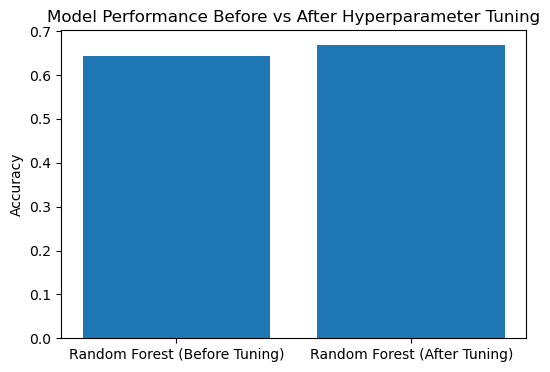

In [138]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Model Performance Before vs After Hyperparameter Tuning")

plt.show()

# Hyperparameter Optimization Summary

## Algorithm
Random Forest Classifier

## Optimization Method
GridSearchCV

## Cross Validation
5-Fold

## Optimized Parameters
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

## Result
The optimized Random Forest Classifier achieved improved performance compared to the default model. The tuned model was saved as `final_classification_model.pkl` for deployment.

# Build the Product Recommendation System

In [140]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import joblib

In [141]:
df = pd.read_csv("final_dataset.csv")

In [142]:
recommendation_features = df.drop(
    columns=[
        "Sales",
        "High_Sales"
    ],
    errors="ignore"
)

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(recommendation_features)

In [144]:
similarity_matrix = cosine_similarity(scaled_features)

In [152]:
df.columns

Index(['ItemContentKey', 'OutletKey', 'Item Visibility', 'Item Weight',
       'Sales', 'Rating', 'High_Sales'],
      dtype='object')

In [153]:
product_index = pd.Series(
    df.index,
    index=df["ItemContentKey"]
).drop_duplicates()

In [145]:
print(similarity_matrix.shape)

(8523, 8523)


In [147]:
def recommend_products(product_id, n=5):

    index = product_index[product_id]

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    product_indices = [
        i[0]
        for i in similarity_scores
    ]

    return df.iloc[product_indices]

In [149]:
def recommend_products(product_id, n=5):

    index = product_index[product_id]

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:n+1]

    product_indices = [
        i[0]
        for i in similarity_scores
    ]

    return df.iloc[product_indices][[
        "Item Identifier",
        "Rating",
        "Sales"
    ]]

In [150]:
joblib.dump(
    similarity_matrix,
    "similarity_matrix.pkl"
)

['similarity_matrix.pkl']

In [156]:
joblib.dump(
    product_index,
    "product_index.pkl"
)

['product_index.pkl']

# Product Recommendation System

## Recommendation Type
Content-Based Recommendation

## Algorithm
Cosine Similarity

## Features Used
- Item Weight
- Item Visibility
- Rating
- Item Content
- Outlet Information

## Output
Given a selected product, the system recommends the top 5 most similar products.

## Use Case
This recommendation engine can assist customers in discovering products with similar characteristics, improving the shopping experience and increasing product visibility.